In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from scipy.sparse import hstack
import joblib

from scipy.sparse import hstack
from xgboost import XGBClassifier

In [3]:
from scipy.sparse import load_npz

X = load_npz("X_tfidf_main1.npz")

In [4]:
import pandas as pd

df = pd.read_csv("final_labeled_feedback.csv")
train_df = df[
    [
        "clean_text",
        "rating",
        "thumbs_up",
        "review_length",
        "word_count",
        "has_reply",
        "category"
    ]
].copy()

In [5]:
df.head()

,app_id,app_name,review_id,user_name,review_text,rating,thumbs_up,review_date,reply_text,reply_date,sentiment,category,priority,clean_text,review_length,word_count,has_reply,review_month,source,prediction_confidence
0,com.google.android.apps.nbu.paisa.user,gpay,a4c065f0-b2c9-4db0-b553-e11c63152a3f,Simmi Bagga,very good,5,0,2026-06-22 11:00:29,NaN,NaN,NaN,Praise,NaN,good,4,1,0,2026-06,playstore,NaN
1,com.flipkart.android,flipkart,35f01bf0-a792-4721-81ce-e7e79c9724a2,Sarla Ukey,best app for shopping,5,0,2026-06-23 23:02:04,"Hi Flipkart User, Thank you so much for your f...",2026-06-24 09:09:38,NaN,Praise,NaN,best app shopping,17,3,1,2026-06,playstore,NaN
2,in.swiggy.android,swiggy,9a8b21c8-5fa3-4b2c-af57-b964f473f205,Lucky Rajput,had se jyada mehnga hai milta hai service kr n...,3,0,2026-06-23 14:02:14,"Hi, sorry to know this. We would like to know ...",2026-06-23 14:02:38,NaN,Praise,NaN,se jyada mehnga hai milta hai service kr naam par,49,10,1,2026-06,playstore,NaN
3,com.microsoft.teams,Microsoft Teams,4fadab87-6e01-41a3-a2b0-47cb4a37c523,Leigh Timm,"Works ok, but experienced some bugs.",4,0,2026-06-27 15:18:28,NaN,NaN,NaN,Complaint,NaN,works ok experienced bugs,25,4,0,2026-06,playstore,0.5118
4,com.google.android.youtube,youtube,c6e4db27-05fa-4694-9756-49a6a203d905,Anila Aslam,Hassan asim Hussain Asim,5,0,2026-06-23 22:19:55,NaN,NaN,NaN,Praise,NaN,hassan asim hussain asim,24,4,0,2026-06,playstore,NaN


In [6]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["category"])

In [7]:
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

0 -> Bug
1 -> Complaint
2 -> Feature Request
3 -> Performance Issue
4 -> Praise
5 -> UI Issue


In [8]:
from sklearn.preprocessing import LabelEncoder
import joblib
import os


encoder = LabelEncoder()

y = encoder.fit_transform(
    df["category"]
)


for i, c in enumerate(encoder.classes_):
    print(i, "->", c)


# create folder if not exists
os.makedirs("models", exist_ok=True)


# save encoder
joblib.dump(
    encoder,
    "label_encoder.pkl"
)

0 -> Bug
1 -> Complaint
2 -> Feature Request
3 -> Performance Issue
4 -> Praise
5 -> UI Issue


['label_encoder.pkl']

In [54]:
print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (79606, 7000)
y shape: (79606,)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
train_df = train_df.dropna(
    subset=["category"]
)

In [57]:
print(train_df["category"].value_counts())

category
Praise               33982
Complaint            29903
Feature Request       4097
UI Issue              4000
Performance Issue     4000
Bug                   3624
Name: count, dtype: int64


In [58]:
sample_weights = compute_sample_weight(

    class_weight="balanced",

    y=y_train

)

In [59]:
model = XGBClassifier(

    objective="multi:softprob",

    num_class=len(encoder.classes_),

    n_estimators=400,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1,

    random_state=42,

    eval_metric="mlogloss",

    n_jobs=-1

)

In [60]:
model.fit(X_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [61]:
model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights

)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [62]:
y_pred = model.predict(X_test)

In [63]:
print(
accuracy_score(
    y_test,
    y_pred
)
)

0.8819243813591258


In [64]:
print(
classification_report(

    y_test,

    y_pred,

    target_names=encoder.classes_

)
)

                   precision    recall  f1-score   support

              Bug       0.36      1.00      0.53       725
        Complaint       0.97      0.82      0.89      5981
  Feature Request       0.80      0.99      0.88       819
Performance Issue       1.00      1.00      1.00       800
           Praise       0.96      0.89      0.92      6797
         UI Issue       1.00      1.00      1.00       800

         accuracy                           0.88     15922
        macro avg       0.85      0.95      0.87     15922
     weighted avg       0.93      0.88      0.90     15922



In [65]:
import numpy as np
probability = model.predict_proba(X_test)

confidence = np.max(
    probability,
    axis=1
)

In [66]:
import numpy as np

# Predict class
predictions = model.predict(X_test)

# Predict probabilities
probabilities = model.predict_proba(X_test)

# Get confidence for each prediction
confidence = np.max(probabilities, axis=1)

# Process each review
for review, pred, conf in zip(X_test, predictions, confidence):

    if conf < 0.75:
        print("➡ Low confidence:", conf)
        # Send this review to Gemini/BERT/LLM
        # genai_result = send_to_genai(review)

    else:
        print("➡ XGBoost prediction:", pred, "| Confidence:", conf)

➡ XGBoost prediction: 4 | Confidence: 0.98722434
➡ XGBoost prediction: 5 | Confidence: 0.99952066
➡ XGBoost prediction: 4 | Confidence: 0.9817873
➡ XGBoost prediction: 1 | Confidence: 0.89368296
➡ Low confidence: 0.7028307
➡ XGBoost prediction: 4 | Confidence: 0.98722434
➡ XGBoost prediction: 1 | Confidence: 0.77292275
➡ Low confidence: 0.34489018
➡ XGBoost prediction: 2 | Confidence: 0.88425744
➡ XGBoost prediction: 4 | Confidence: 0.86291355
➡ XGBoost prediction: 1 | Confidence: 0.95691806
➡ XGBoost prediction: 4 | Confidence: 0.98722434
➡ XGBoost prediction: 1 | Confidence: 0.77474463
➡ XGBoost prediction: 4 | Confidence: 0.86291355
➡ XGBoost prediction: 4 | Confidence: 0.98722434
➡ XGBoost prediction: 4 | Confidence: 0.9894986
➡ XGBoost prediction: 4 | Confidence: 0.9817873
➡ Low confidence: 0.38320985
➡ Low confidence: 0.4844441
➡ XGBoost prediction: 1 | Confidence: 0.93981624
➡ Low confidence: 0.67223203
➡ XGBoost prediction: 4 | Confidence: 0.7725743
➡ Low confidence: 0.7382693


In [67]:
joblib.dump(
   model, "xgboost_feedback_model.pkl"
)



['xgboost_feedback_model.pkl']

[[ 722    0    0    0    3    0]
 [ 722 4875  146    0  238    0]
 [   3    0  807    0    9    0]
 [   0    0    0  800    0    0]
 [ 576  125   58    0 6038    0]
 [   0    0    0    0    0  800]]


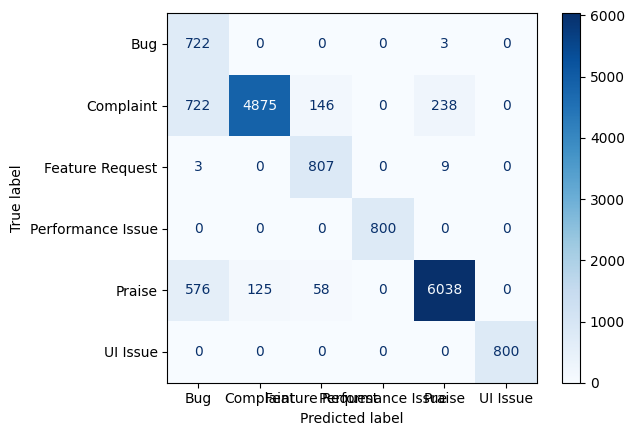

In [68]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.show()

In [69]:
print(encoder.classes_)

['Bug' 'Complaint' 'Feature Request' 'Performance Issue' 'Praise'
 'UI Issue']


In [70]:
test_reviews = [
    "App crashes every time I open it.",
    "Please add dark mode.",
    "Amazing application, loved it.",
    "Too many ads after latest update.",
    "Payment failed twice.",
    "Excellent UI and smooth experience."
]

for review in test_reviews:

    vector = tfidf.transform([review])

    numeric = [[
        1,              # rating
        0,              # thumbs_up
        len(review),    # review_length
        len(review.split()),  # word_count
        0               # has_reply
    ]]

    from scipy.sparse import hstack

    X_new = hstack([vector, numeric])

    pred = model.predict(X_new)

    label = encoder.inverse_transform(pred)[0]

    print(review)
    print("Prediction:", label)
    print("-"*50)

NameError: name 'tfidf' is not defined